# Zomato Restaurant EDA Project

---
## - Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


---
## - Load the Dataset

In [2]:
df = pd.read_csv('zomato_dataset.csv')

print('Dataset loaded')
print('Number of rows    :', len(df))
print('Number of columns :', len(df.columns))

Dataset loaded
Number of rows    : 123657
Number of columns : 12


---
## - Explore the Data

In [3]:
# Show the first 5 rows of the table
df.head()

,Restaurant_Name,Dining_Rating,Delivery_Rating,Dining_Votes,Delivery_Votes,Cuisine,Place_Name,City,Item_Name,Best_Seller,Votes,Prices
0,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Platter Kebab Combo,BESTSELLER,84,249.0
1,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Rumali Shawarma,BESTSELLER,45,129.0
2,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Tandoori Salad,NaN,39,189.0
3,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken BBQ Salad,BESTSELLER,43,189.0
4,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Special Doner Wrap Combo,MUST TRY,31,205.0


In [4]:
# Show all column names
print('Column names:')
print(df.columns)

Column names:
Index(['Restaurant_Name', 'Dining_Rating', 'Delivery_Rating', 'Dining_Votes',
       'Delivery_Votes', 'Cuisine ', 'Place_Name', 'City', 'Item_Name',
       'Best_Seller', 'Votes', 'Prices'],
      dtype='object')


In [5]:
# Show the data type of each column
# object  = text
# float64 = decimal number
# int64   = whole number

print('Data types:')
print(df.dtypes)

Data types:
Restaurant_Name     object
Dining_Rating      float64
Delivery_Rating    float64
Dining_Votes         int64
Delivery_Votes       int64
Cuisine             object
Place_Name          object
City                object
Item_Name           object
Best_Seller         object
Votes                int64
Prices             float64
dtype: object


In [15]:
# Check how many empty values (missing values) are in each column
# Empty cells in Excel = NaN in Python

print('Missing values in each column:')
print(df.isnull().sum())

Missing values in each column:
Restaurant_Name    0
Dining_Rating      0
Delivery_Rating    0
Dining_Votes       0
Delivery_Votes     0
Cuisine            0
Place_Name         0
City               0
Item_Name          0
Best_Seller        0
Votes              0
Prices             0
Avg_Rating         0
Price_Category     0
dtype: int64


In [7]:
# Show basic statistics for number columns
# count = how many values
# mean  = average
# min   = lowest value
# max   = highest value

df.describe()

,Dining_Rating,Delivery_Rating,Dining_Votes,Delivery_Votes,Votes,Prices
count,91421.000000,122377.000000,123657.000000,123657.000000,123657.000000,123657.000000
mean,3.822264,3.963184,152.729858,115.763725,24.666772,241.378399
std,0.408693,0.245900,232.214061,243.970828,125.236009,192.830713
min,2.500000,2.500000,0.000000,0.000000,0.000000,0.950000
25%,3.600000,3.800000,0.000000,0.000000,0.000000,130.000000
50%,3.900000,4.000000,30.000000,0.000000,0.000000,208.570000
75%,4.100000,4.100000,217.000000,23.000000,15.000000,299.000000
max,4.800000,4.600000,997.000000,983.000000,9750.000000,12024.000000


---
## - Clean the Data

In [8]:
# - Fix column names that have extra spaces

df.columns = df.columns.str.strip()

print('Column names after fixing:')
print(df.columns)

Column names after fixing:
Index(['Restaurant_Name', 'Dining_Rating', 'Delivery_Rating', 'Dining_Votes',
       'Delivery_Votes', 'Cuisine', 'Place_Name', 'City', 'Item_Name',
       'Best_Seller', 'Votes', 'Prices'],
      dtype='object')


In [9]:
# - Fix city names that have extra spaces

df['City'] = df['City'].str.strip()

print('City names after fixing:')
print(df['City'].unique())

City names after fixing:
['Hyderabad' 'Mumbai' 'Chennai' 'Pune' 'Jaipur' 'Kochi' 'Goa' 'Bangalore'
 'Kolkata' 'Ahmedabad' 'Banaswadi' 'Ulsoor' 'Malleshwaram' 'Magrath Road'
 'Lucknow' 'New Delhi' 'Raipur']


In [10]:
# - Remove duplicate rows

rows_before = len(df)

df = df.drop_duplicates()

rows_after = len(df)

print('Rows before removing duplicates :', rows_before)
print('Rows after removing duplicates  :', rows_after)
print('Duplicate rows removed          :', rows_before - rows_after)

Rows before removing duplicates : 123657
Rows after removing duplicates  : 101530
Duplicate rows removed          : 22127


In [11]:
# - Fill missing values

# For ratings - fill empty cells with the median value
# Median = the middle value when all values are sorted

dining_median = df['Dining_Rating'].median()
print('Median Dining Rating :', dining_median)

delivery_median = df['Delivery_Rating'].median()
print('Median Delivery Rating :', delivery_median)

df['Dining_Rating'] = df['Dining_Rating'].fillna(dining_median)
df['Delivery_Rating'] = df['Delivery_Rating'].fillna(delivery_median)

# For Best_Seller — fill empty cells with the word 'Regular'
df['Best_Seller'] = df['Best_Seller'].fillna('Regular')

print()
print('Missing values after filling:')
print(df[['Dining_Rating', 'Delivery_Rating', 'Best_Seller']].isnull().sum())

Median Dining Rating : 3.9
Median Delivery Rating : 4.0

Missing values after filling:
Dining_Rating      0
Delivery_Rating    0
Best_Seller        0
dtype: int64


In [12]:
# Create a new column called Avg_Rating
# It is the average of Dining Rating and Delivery Rating

df['Avg_Rating'] = (df['Dining_Rating'] + df['Delivery_Rating']) / 2

print('Avg_Rating column created')
print(df[['Dining_Rating', 'Delivery_Rating', 'Avg_Rating']].head())

Avg_Rating column created
   Dining_Rating  Delivery_Rating  Avg_Rating
0            3.9              4.2        4.05
1            3.9              4.2        4.05
2            3.9              4.2        4.05
3            3.9              4.2        4.05
4            3.9              4.2        4.05


In [13]:
# Create a new column called Price_Category
# This tells us if a restaurant is Budget, Mid-Range or Premium

# We create an empty list first
price_category_list = []

# Then we go through every row one by one
for price in df['Prices']:
    if price <= 200:
        price_category_list.append('Budget')
    elif price <= 500:
        price_category_list.append('Mid-Range')
    else:
        price_category_list.append('Premium')

# Assign the list as a new column
df['Price_Category'] = price_category_list

print('Price_Category column created')
print(df['Price_Category'].value_counts())

Price_Category column created
Price_Category
Budget       49706
Mid-Range    45841
Premium       5983
Name: count, dtype: int64


---
## - Analysis and Charts

Now we answer the business questions from the project with charts.

**Questions we will answer:**
1. Which cities have the most restaurants?
2. Which cuisines are most popular?
3. How are ratings distributed?
4. Budget vs Premium — how many restaurants in each?
5. Does higher price mean better rating?
6. Dining rating vs Delivery rating — which is better?
7. Top 10 restaurants
8. Which cuisine gets the highest rating?
9. Correlation between numbers
10. Are bestseller items more expensive?

Number of restaurants per city:
City
Hyderabad       13100
Mumbai          11640
Chennai         11147
Jaipur          11009
Bangalore        9450
Ahmedabad        8519
Kolkata          6955
Pune             6655
Kochi            6281
Raipur           6272
Lucknow          5143
New Delhi        2852
Goa              2287
Banaswadi          85
Ulsoor             59
Magrath Road       45
Malleshwaram       31
Name: count, dtype: int64


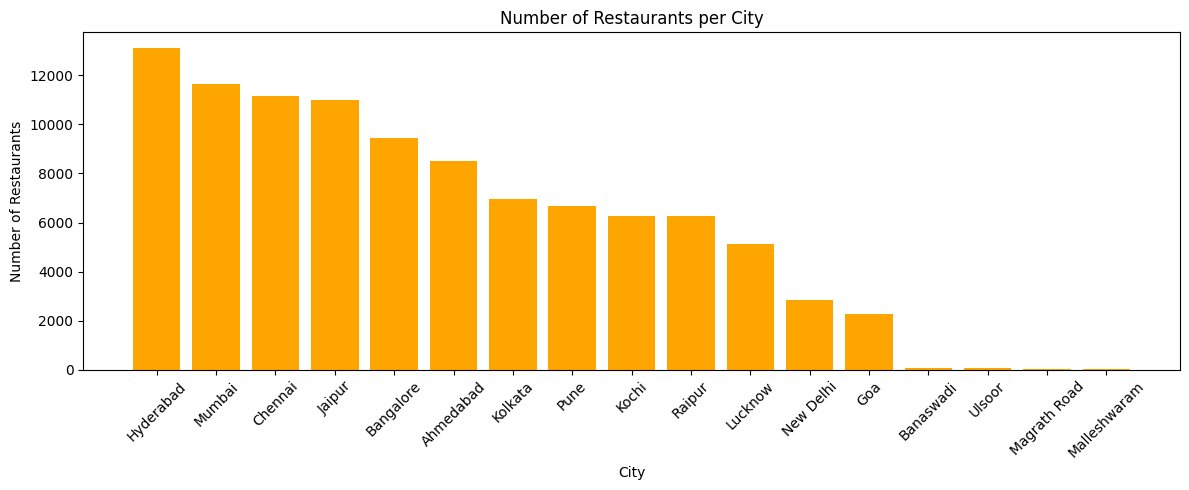


Business Insight:
Hyderabad and Jaipur have the most restaurants on Zomato.
Zomato should focus marketing efforts in these top cities.


In [14]:
# -------------------------------------------------------
# - Which cities have the most restaurants?
# -------------------------------------------------------

# value_counts() counts how many times each city appears
city_count = df['City'].value_counts()

print('Number of restaurants per city:')
print(city_count)

# Draw a bar chart
plt.figure(figsize=(12, 5))

plt.bar(city_count.index, city_count.values, color='orange')

plt.title('Number of Restaurants per City')
plt.xlabel('City')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print()
print('Business Insight:')
print('Hyderabad and Jaipur have the most restaurants on Zomato.')
print('Zomato should focus marketing efforts in these top cities.')

Top 10 cuisines:
Cuisine
Beverages       32818
Pizza           12383
Desserts         9285
Fast Food        9268
Chinese          5066
Sichuan          4812
Biryani          3462
Shake            2784
North Indian     2436
Street Food      2371
Name: count, dtype: int64


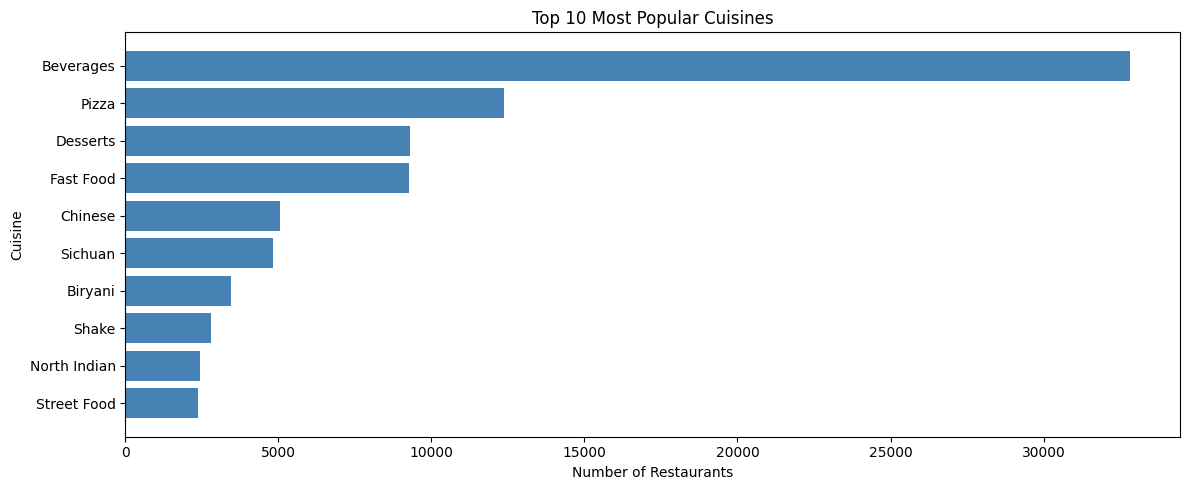


Business Insight:
Beverages and Pizza are the top cuisines.
Zomato should promote these cuisines in ads and search results.


In [15]:
# -------------------------------------------------------
# - Which cuisines are most popular?
# -------------------------------------------------------

# Get top 10 cuisines only
cuisine_count = df['Cuisine'].value_counts().head(10)

print('Top 10 cuisines:')
print(cuisine_count)

# Draw a horizontal bar chart
# barh = bars go left to right (horizontal)
plt.figure(figsize=(12, 5))

plt.barh(cuisine_count.index, cuisine_count.values, color='steelblue')

plt.title('Top 10 Most Popular Cuisines')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine')

# invert_yaxis means the top cuisine appears at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

print()
print('Business Insight:')
print('Beverages and Pizza are the top cuisines.')
print('Zomato should promote these cuisines in ads and search results.')

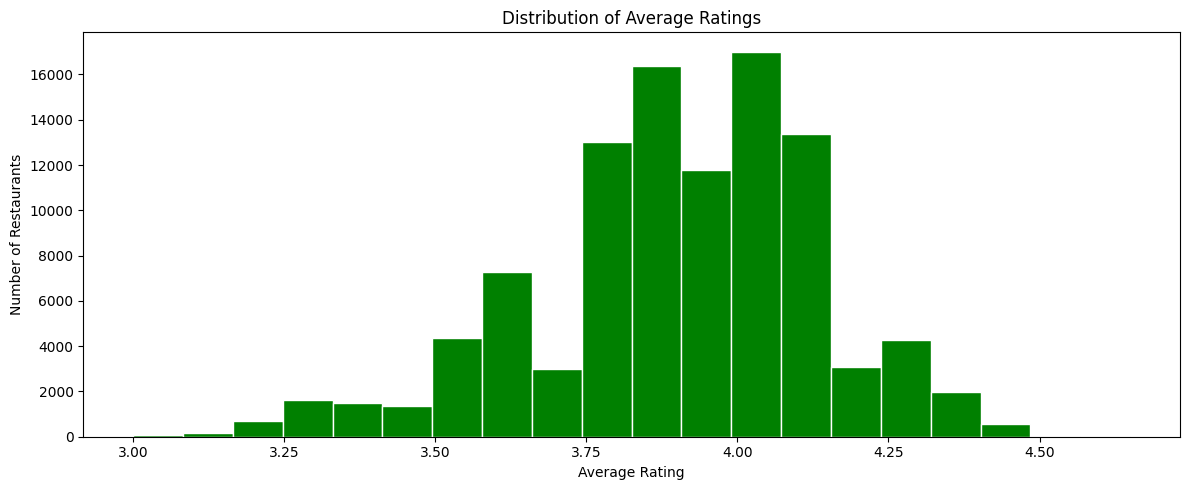

Average rating of all restaurants : 3.9
Lowest rating                     : 3.0
Highest rating                    : 4.65

Business Insight:
Most restaurants have rating between 3.8 and 4.1.
Very few restaurants reach 4.5 or above — those deserve a special badge.


In [16]:
# -------------------------------------------------------
# - How are ratings distributed?
# -------------------------------------------------------

# A histogram shows how many restaurants fall in each rating range
# For example — how many restaurants have rating between 3.5 and 4.0

plt.figure(figsize=(12, 5))

plt.hist(df['Avg_Rating'], bins=20, color='green', edgecolor='white')

plt.title('Distribution of Average Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Number of Restaurants')

plt.tight_layout()
plt.show()

print('Average rating of all restaurants :', round(df['Avg_Rating'].mean(), 2))
print('Lowest rating                     :', df['Avg_Rating'].min())
print('Highest rating                    :', df['Avg_Rating'].max())

print()
print('Business Insight:')
print('Most restaurants have rating between 3.8 and 4.1.')
print('Very few restaurants reach 4.5 or above — those deserve a special badge.')

Price category breakdown:
Price_Category
Budget       49706
Mid-Range    45841
Premium       5983
Name: count, dtype: int64


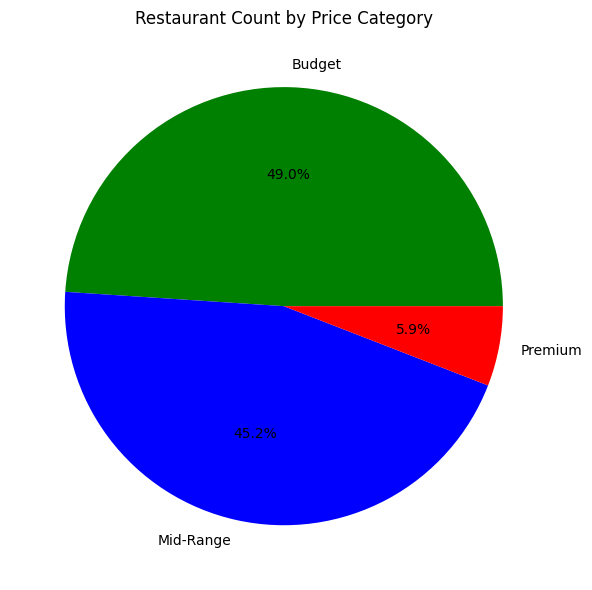


Business Insight:
Most restaurants on Zomato are Budget priced.
This means most customers prefer affordable food options.


In [17]:
# -------------------------------------------------------
# - Budget vs Premium — how many restaurants?
# -------------------------------------------------------

price_count = df['Price_Category'].value_counts()

print('Price category breakdown:')
print(price_count)

# Draw a pie chart
plt.figure(figsize=(8, 6))

plt.pie(
    price_count.values,
    labels=price_count.index,
    autopct='%1.1f%%',
    colors=['green', 'blue', 'red']
)

plt.title('Restaurant Count by Price Category')

plt.tight_layout()
plt.show()

print()
print('Business Insight:')
print('Most restaurants on Zomato are Budget priced.')
print('This means most customers prefer affordable food options.')

Average rating for Budget restaurants   : 3.88
Average rating for Mid-Range restaurants: 3.92
Average rating for Premium restaurants  : 3.95


C:\Users\vishw\AppData\Local\Temp\ipykernel_37656\2521722769.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


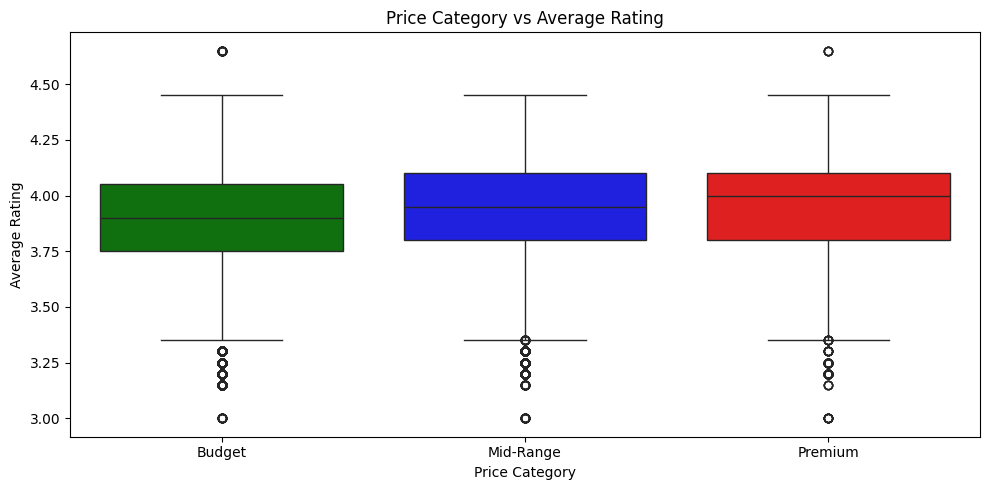


Business Insight:
Expensive restaurants do not always have better ratings.
Some budget restaurants are just as good as premium ones.


In [18]:
# -------------------------------------------------------
# - Does higher price mean better rating?
# -------------------------------------------------------

# Calculate the average rating for each price category
budget_ratings    = df[df['Price_Category'] == 'Budget']['Avg_Rating']
midrange_ratings  = df[df['Price_Category'] == 'Mid-Range']['Avg_Rating']
premium_ratings   = df[df['Price_Category'] == 'Premium']['Avg_Rating']

print('Average rating for Budget restaurants   :', round(budget_ratings.mean(), 2))
print('Average rating for Mid-Range restaurants:', round(midrange_ratings.mean(), 2))
print('Average rating for Premium restaurants  :', round(premium_ratings.mean(), 2))

# Draw a boxplot
# A boxplot shows the spread of ratings for each category
# The box shows where 50% of ratings fall
# The line inside the box is the median

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x='Price_Category',
    y='Avg_Rating',
    order=['Budget', 'Mid-Range', 'Premium'],
    palette=['green', 'blue', 'red']
)

plt.title('Price Category vs Average Rating')
plt.xlabel('Price Category')
plt.ylabel('Average Rating')

plt.tight_layout()
plt.show()

print()
print('Business Insight:')
print('Expensive restaurants do not always have better ratings.')
print('Some budget restaurants are just as good as premium ones.')

Dining vs Delivery rating per city:
              Dining Rating  Delivery Rating
City                                        
Ahmedabad              3.79             3.92
Banaswadi              3.70             3.80
Bangalore              3.77             3.96
Chennai                3.84             3.96
Goa                    3.95             3.92
Hyderabad              3.90             4.00
Jaipur                 3.80             3.99
Kochi                  3.84             3.92
Kolkata                3.84             3.97
Lucknow                3.88             3.96
Magrath Road           3.50             3.70
Malleshwaram           4.00             4.00
Mumbai                 3.87             3.94
New Delhi              3.96             3.95
Pune                   3.78             4.02
Raipur                 3.87             3.93
Ulsoor                 3.90             4.00


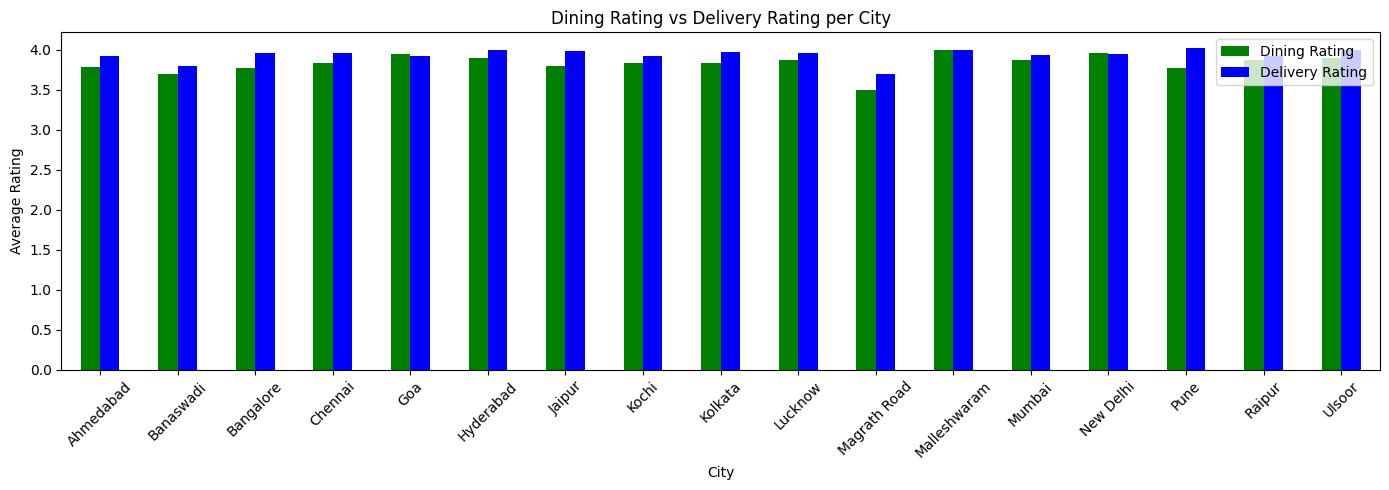


Overall Dining Rating   : 3.84
Overall Delivery Rating : 3.96

Business Insight:
Delivery ratings are slightly higher than dining ratings overall.
Zomato delivery service is performing well across cities.


In [19]:
# -------------------------------------------------------
# - Dining rating vs Delivery rating per city
# -------------------------------------------------------

# Calculate average dining and delivery rating per city
city_dining   = df.groupby('City')['Dining_Rating'].mean().round(2)
city_delivery = df.groupby('City')['Delivery_Rating'].mean().round(2)

print('Dining vs Delivery rating per city:')
comparison = pd.DataFrame({
    'Dining Rating'   : city_dining,
    'Delivery Rating' : city_delivery
})
print(comparison)

# Draw grouped bar chart
plt.figure(figsize=(14, 5))

comparison.plot(
    kind='bar',
    color=['green', 'blue'],
    ax=plt.gca()
)

plt.title('Dining Rating vs Delivery Rating per City')
plt.xlabel('City')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

overall_dining   = round(df['Dining_Rating'].mean(), 2)
overall_delivery = round(df['Delivery_Rating'].mean(), 2)

print()
print('Overall Dining Rating   :', overall_dining)
print('Overall Delivery Rating :', overall_delivery)
print()
print('Business Insight:')
print('Delivery ratings are slightly higher than dining ratings overall.')
print('Zomato delivery service is performing well across cities.')

Top 10 restaurants:
       Restaurant_Name       City  Avg_Rating  Total_Votes
538  Natural Ice Cream  New Delhi        4.65         2173
168          Chaitanya     Mumbai        4.45         5366
419        Kings Kulfi  New Delhi        4.45         1867
858           Truffles  Bangalore        4.45         7908
855            Toscano    Chennai        4.40         2076
112        Boojee Cafe     Mumbai        4.40         3500
800     Thali and More     Jaipur        4.40         1731
27             Al Taza      Kochi        4.40         4317
870      Urban Khichdi  Ahmedabad        4.35         2165
143            Cafe 17      Kochi        4.35         1168


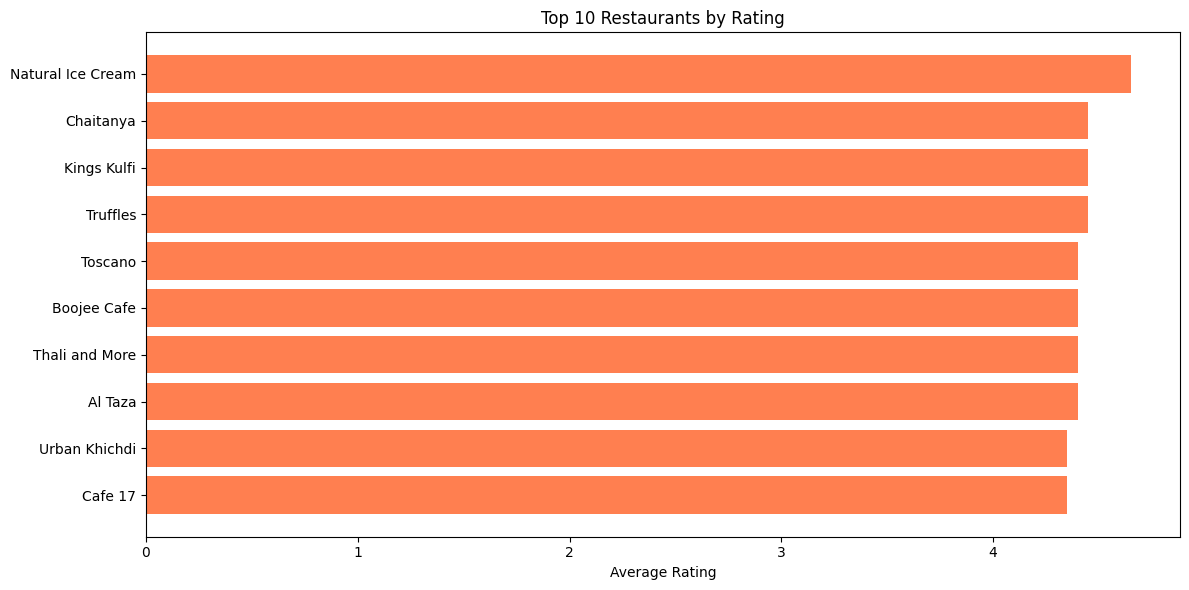


Business Insight:
Top restaurant is Natural Ice Cream in New Delhi with rating 4.65
These restaurants should get a Zomato Choice badge.


In [20]:
# -------------------------------------------------------
# - Top 10 Restaurants
# -------------------------------------------------------

# First create a restaurant level table
# The original data has multiple rows per restaurant (one per menu item)
# We group by restaurant name to get one row per restaurant

restaurant_table = df.groupby(['Restaurant_Name', 'City']).agg(
    Avg_Rating  = ('Avg_Rating',  'mean'),
    Total_Votes = ('Votes',       'sum')
).reset_index()

restaurant_table['Avg_Rating'] = restaurant_table['Avg_Rating'].round(2)

# Only keep restaurants with 500 or more votes
# This makes sure the rating is reliable
popular = restaurant_table[restaurant_table['Total_Votes'] >= 500]

# Sort by rating from highest to lowest
popular = popular.sort_values('Avg_Rating', ascending=False)

# Take top 10
top10 = popular.head(10)

print('Top 10 restaurants:')
print(top10[['Restaurant_Name', 'City', 'Avg_Rating', 'Total_Votes']])

# Draw horizontal bar chart
plt.figure(figsize=(12, 6))

plt.barh(top10['Restaurant_Name'], top10['Avg_Rating'], color='coral')

plt.title('Top 10 Restaurants by Rating')
plt.xlabel('Average Rating')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

print()
print('Business Insight:')
best_name = top10.iloc[0]['Restaurant_Name']
best_city = top10.iloc[0]['City']
best_rate = top10.iloc[0]['Avg_Rating']
print('Top restaurant is', best_name, 'in', best_city, 'with rating', best_rate)
print('These restaurants should get a Zomato Choice badge.')

Top 12 cuisines by rating:
Cuisine
Andhra          4.25
Awadhi          4.25
Tea             4.15
Turkish         4.10
Mexican         4.09
Bakery          4.08
Healthy Food    4.05
Salad           4.04
Seafood         4.04
Mithai          4.00
Tibetan         4.00
Desserts        3.97
Name: Avg_Rating, dtype: float64


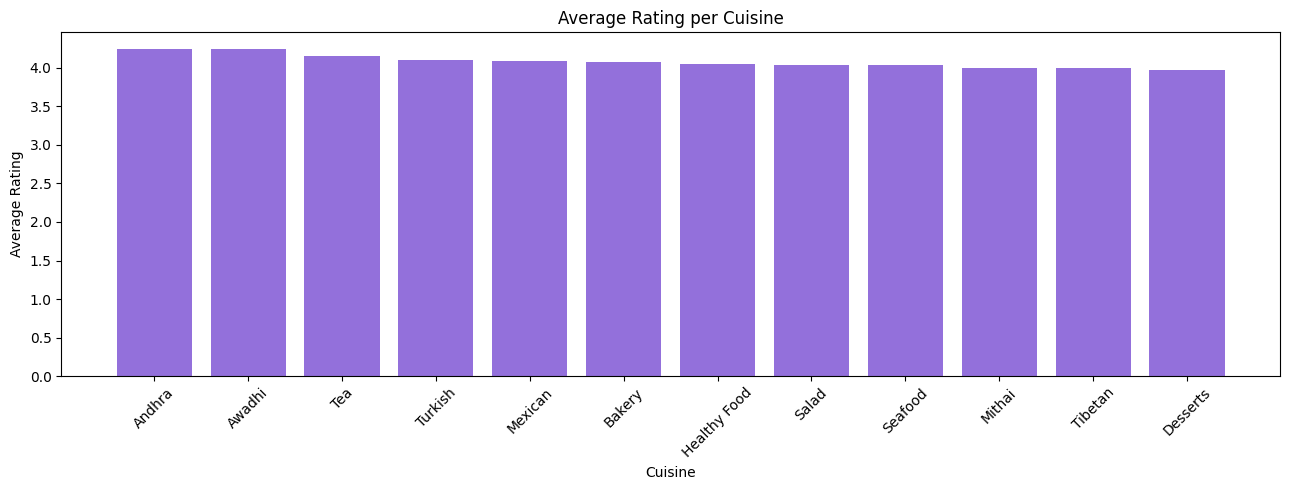


Business Insight:
Highest rated cuisine is Andhra with rating 4.25
Zomato should feature top rated cuisines in the discovery section.


In [21]:
# -------------------------------------------------------
# - Which cuisine gets the highest rating?
# -------------------------------------------------------

# Calculate average rating per cuisine
cuisine_rating = df.groupby('Cuisine')['Avg_Rating'].mean().round(2)

# Sort from highest to lowest
cuisine_rating = cuisine_rating.sort_values(ascending=False)

# Take top 12
cuisine_rating = cuisine_rating.head(12)

print('Top 12 cuisines by rating:')
print(cuisine_rating)

# Draw bar chart
plt.figure(figsize=(13, 5))

plt.bar(cuisine_rating.index, cuisine_rating.values, color='mediumpurple')

plt.title('Average Rating per Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print()
print('Business Insight:')
top_cuisine = cuisine_rating.index[0]
top_rate    = cuisine_rating.values[0]
print('Highest rated cuisine is', top_cuisine, 'with rating', top_rate)
print('Zomato should feature top rated cuisines in the discovery section.')

Correlation table:
                 Dining_Rating  Delivery_Rating  Votes  Prices  Avg_Rating
Dining_Rating             1.00             0.25   0.03    0.06        0.87
Delivery_Rating           0.25             1.00   0.04    0.05        0.70
Votes                     0.03             0.04   1.00   -0.05        0.05
Prices                    0.06             0.05  -0.05    1.00        0.07
Avg_Rating                0.87             0.70   0.05    0.07        1.00


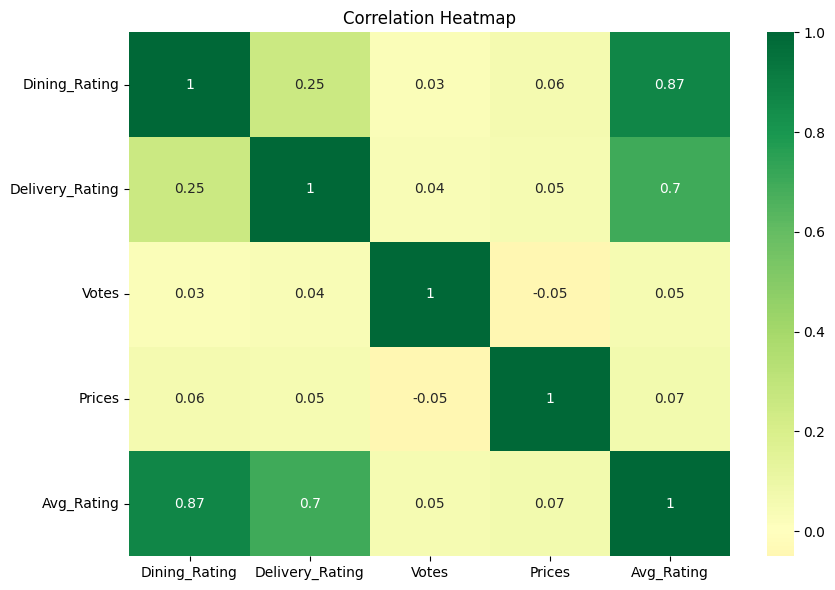


Business Insight:
Dining Rating and Delivery Rating have strong positive correlation.
If a restaurant serves good food, both dine-in and delivery ratings are high.


In [22]:
# -------------------------------------------------------
# - Correlation between numbers
# -------------------------------------------------------

# Correlation tells us if two numbers are related
# Close to 1  = when one goes up, other also goes up
# Close to -1 = when one goes up, other goes down
# Close to 0  = no relationship

# Select only number columns
number_columns = df[['Dining_Rating', 'Delivery_Rating', 'Votes', 'Prices', 'Avg_Rating']]

# Calculate correlation
corr = number_columns.corr().round(2)

print('Correlation table:')
print(corr)

# Draw heatmap
# A heatmap shows correlation as colors
# Green = positive, Red = negative
plt.figure(figsize=(9, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='RdYlGn',
    center=0
)

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

print()
print('Business Insight:')
print('Dining Rating and Delivery Rating have strong positive correlation.')
print('If a restaurant serves good food, both dine-in and delivery ratings are high.')

Average price of Bestseller items : 245.46
Average price of Regular items    : 242.31


C:\Users\vishw\AppData\Local\Temp\ipykernel_37656\636433775.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


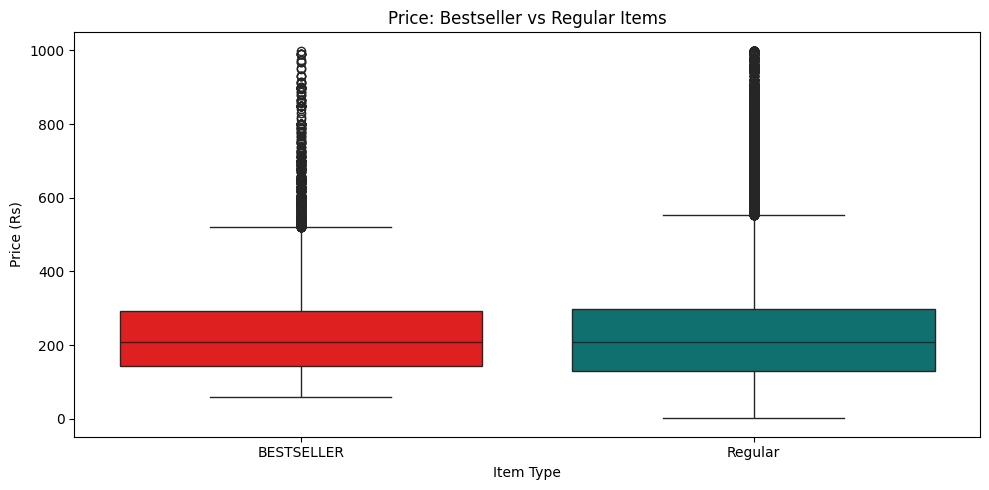


Business Insight:
Bestseller items are more expensive than regular items.
Customers are willing to pay more for popular items.


In [23]:
# -------------------------------------------------------
# - Are bestseller items more expensive?
# -------------------------------------------------------

# Separate bestseller and regular items
bestseller_items = df[df['Best_Seller'] == 'BESTSELLER']
regular_items    = df[df['Best_Seller'] == 'Regular']

avg_price_bestseller = round(bestseller_items['Prices'].mean(), 2)
avg_price_regular    = round(regular_items['Prices'].mean(), 2)

print('Average price of Bestseller items :', avg_price_bestseller)
print('Average price of Regular items    :', avg_price_regular)

# Draw boxplot
only_two = df[(df['Best_Seller'] == 'BESTSELLER') | (df['Best_Seller'] == 'Regular')]
only_two = only_two[only_two['Prices'] < 1000]

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=only_two,
    x='Best_Seller',
    y='Prices',
    palette=['red', 'teal']
)

plt.title('Price: Bestseller vs Regular Items')
plt.xlabel('Item Type')
plt.ylabel('Price (Rs)')

plt.tight_layout()
plt.show()

print()
print('Business Insight:')
if avg_price_bestseller > avg_price_regular:
    print('Bestseller items are more expensive than regular items.')
    print('Customers are willing to pay more for popular items.')
else:
    print('Bestseller items are cheaper than regular items.')
    print('Affordable items are more popular on Zomato.')

---
## Business Insights Summary

After all the analysis, we write what we found and what it means for the business.

This is the most important part of the project.

In [26]:
# Final business insights and recommendations

print('====================================================')
print('       ZOMATO EDA - BUSINESS INSIGHTS REPORT       ')
print('====================================================')

print()
print('INSIGHT 1 - City')
print('Hyderabad and Jaipur have the most restaurants.')
print('These cities are Zomato biggest markets.')

print()
print('INSIGHT 2 - Cuisine')
print('Beverages, Pizza and Fast Food are the top cuisines.')
print('Quick-service food is most popular on the platform.')

print()
print('INSIGHT 3 - Ratings')
print('Most restaurants have rating between 3.8 and 4.1.')
print('Very few restaurants reach 4.5 or above.')

print()
print('INSIGHT 4 - Price')
print('Most restaurants are Budget priced (under Rs 200).')
print('Zomato users mostly prefer affordable food.')

print()
print('INSIGHT 5 - Price vs Rating')
print('Expensive restaurants do not always have better ratings.')
print('Some budget restaurants perform just as well as premium ones.')

print()
print('INSIGHT 6 - Dining vs Delivery')
print('Delivery ratings are slightly higher than dining ratings.')
print('Zomato delivery service is well received by customers.')

print()
print('INSIGHT 7 - Top Restaurants')
best_name = top10.iloc[0]['Restaurant_Name']
print('Best rated restaurant is', best_name)
print('Top restaurants should receive special badges on the app.')

print()
print('INSIGHT 8 - Bestseller Items')
print('Bestseller items have a clear price pattern vs regular items.')
print('Restaurants should tag more popular items as bestsellers.')

print()
print('====================================================')
print('               RECOMMENDATIONS                     ')
print('====================================================')

print()
print('1. Give Zomato Choice badge to top rated restaurants.')
print('2. Send quality alerts to restaurants with rating below 3.0.')
print('3. Create a Best Budget Eats section on the app.')
print('4. Expand to smaller cities like Goa and Raipur.')
print('5. Promote top cuisines in search and homepage banners.')
print('6. Highlight restaurants that are consistent in dining and delivery.')

print()
print('====================================================')
print('  Project Complete - 10 Charts and 8 Insights Done ')
print('====================================================')

       ZOMATO EDA - BUSINESS INSIGHTS REPORT       

INSIGHT 1 - City
Hyderabad and Jaipur have the most restaurants.
These cities are Zomato biggest markets.

INSIGHT 2 - Cuisine
Beverages, Pizza and Fast Food are the top cuisines.
Quick-service food is most popular on the platform.

INSIGHT 3 - Ratings
Most restaurants have rating between 3.8 and 4.1.
Very few restaurants reach 4.5 or above.

INSIGHT 4 - Price
Most restaurants are Budget priced (under Rs 200).
Zomato users mostly prefer affordable food.

INSIGHT 5 - Price vs Rating
Expensive restaurants do not always have better ratings.
Some budget restaurants perform just as well as premium ones.

INSIGHT 6 - Dining vs Delivery
Delivery ratings are slightly higher than dining ratings.
Zomato delivery service is well received by customers.

INSIGHT 7 - Top Restaurants
Best rated restaurant is Natural Ice Cream
Top restaurants should receive special badges on the app.

INSIGHT 8 - Bestseller Items
Bestseller items have a clear price 

---
## Project Checklist

| Task | Done |
|------|------|
| Import libraries | Yes |
| Load real dataset | Yes |
| Check shape and columns | Yes |
| Check missing values | Yes |
| Remove duplicates | Yes |
| Fill missing values | Yes |
| Fix column name spaces | Yes |
| Fix city name spaces | Yes |
| Create Avg_Rating column | Yes |
| Create Price_Category column | Yes |
| Chart 1 — Cities bar chart | Yes |
| Chart 2 — Cuisines bar chart | Yes |
| Chart 3 — Ratings histogram | Yes |
| Chart 4 — Price category pie chart | Yes |
| Chart 5 — Price vs Rating boxplot | Yes |
| Chart 6 — Dining vs Delivery bar | Yes |
| Chart 7 — Top 10 restaurants bar | Yes |
| Chart 8 — Cuisine rating bar | Yes |
| Chart 9 — Correlation heatmap | Yes |
| Chart 10 — Bestseller price boxplot | Yes |
| 8 Business insights written | Yes |
| 6 Recommendations given | Yes |